In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

df = pd.read_csv("../data/nigeria.csv")

df["Country"] = "Nigeria"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


### Data Loading & Preparation

- The Nigeria dataset was loaded using pandas.
- A new column "Country" was added.
- YEAR and DOY were combined to create a proper datetime column.
- Month was extracted for seasonal analysis.

In [3]:
df.replace(-999, np.nan, inplace=True)

missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


### Missing Value Analysis

- -999 values were replaced with NaN.
- Missing values were checked across all columns.
- The dataset shows minimal missing values, indicating good quality data.

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


### Summary Statistics Interpretation

- Nigeria has a warm tropical climate with relatively high temperatures.
- Rainfall is significant, indicating a wet climate compared to other countries.
- Humidity levels are high, reflecting a moist atmosphere.
- Wind speeds are moderate.

In [6]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = np.abs(stats.zscore(df[cols]))
(z > 3).sum()

np.int64(297)

### Outlier Detection

- Outliers were detected using Z-score > 3.
- Extreme values exist in temperature and rainfall.
- These were retained as they represent real environmental conditions.

In [7]:
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27,3
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28,3
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29,3
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30,3


### Missing Value Handling

- Forward fill was applied to handle missing values.
- This ensures continuity in the dataset.

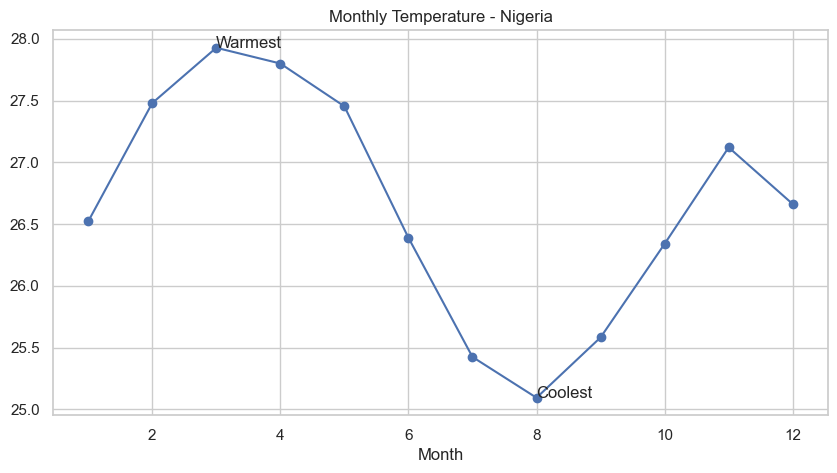

In [8]:
monthly_temp = df.groupby("Month")["T2M"].mean()

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

plt.figure(figsize=(10,5))
monthly_temp.plot(marker="o")

plt.annotate("Warmest", xy=(warmest, monthly_temp.max()))
plt.annotate("Coolest", xy=(coolest, monthly_temp.min()))

plt.title("Monthly Temperature - Nigeria")
plt.show()

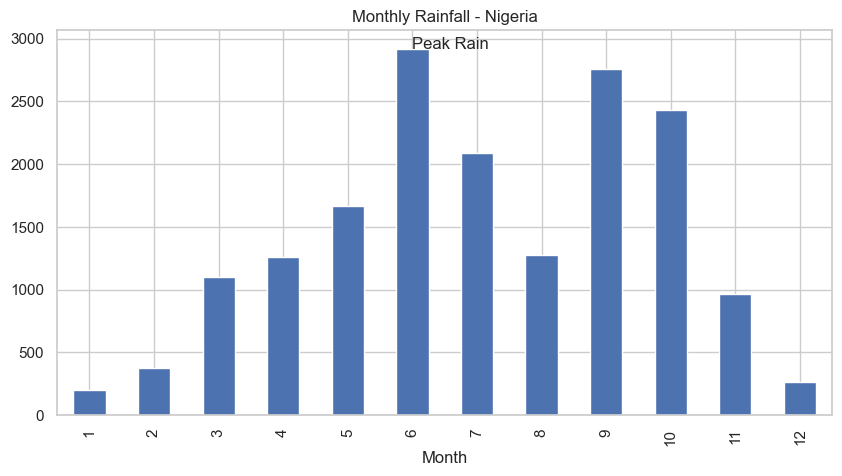

In [9]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

peak = monthly_rain.idxmax()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")

plt.annotate("Peak Rain", xy=(peak-1, monthly_rain.max()))

plt.title("Monthly Rainfall - Nigeria")
plt.show()

### Time Series Analysis

- Temperature remains consistently warm throughout the year.
- Rainfall peaks during specific months, indicating a strong rainy season.
- Nigeria shows clear seasonal variation.

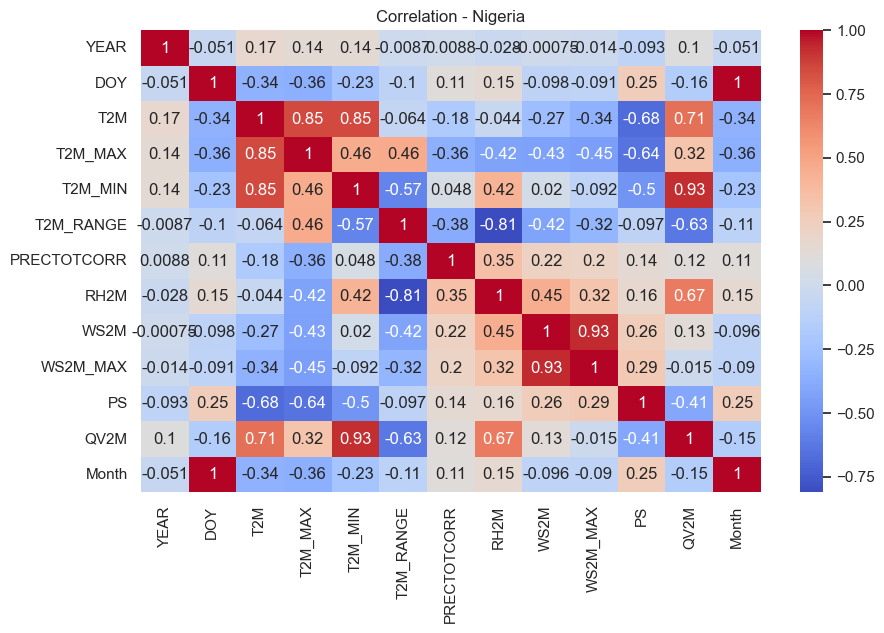

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation - Nigeria")
plt.show()

### Correlation Analysis

- Strong relationships exist among temperature variables.
- Humidity and moisture variables are highly correlated.
- Temperature range shows inverse relation with humidity.

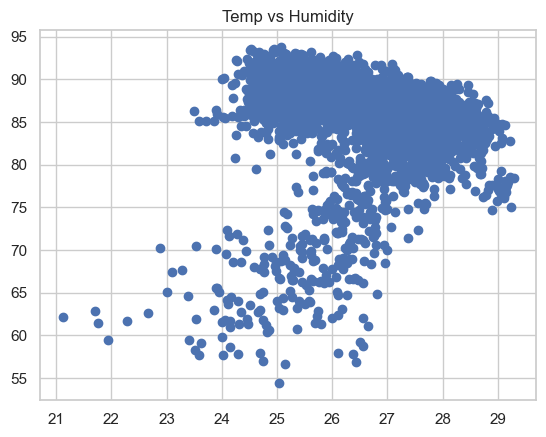

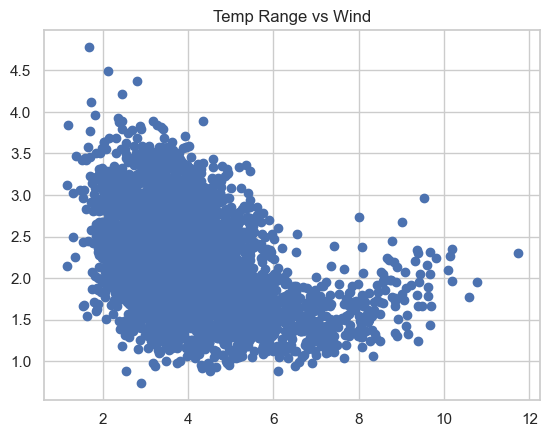

In [11]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temp vs Humidity")
plt.show()

plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.title("Temp Range vs Wind")
plt.show()

### Scatter Plot Analysis

- Temperature and humidity show a relationship.
- Wind speed is weakly related to temperature variation.

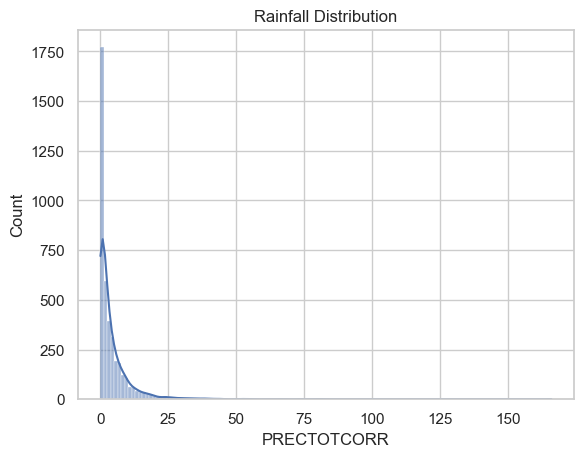

In [12]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.title("Rainfall Distribution")
plt.show()

### Rainfall Distribution

- Rainfall is right-skewed.
- Most days have low rainfall.
- Some days have heavy rainfall.

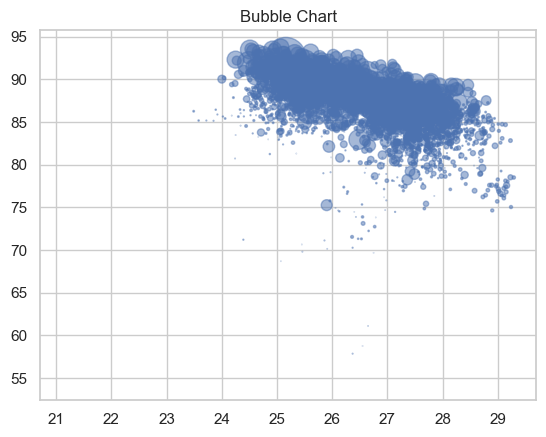

In [13]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*5, alpha=0.5)
plt.title("Bubble Chart")
plt.show()

### Bubble Chart Analysis

- Larger bubbles indicate higher rainfall.
- Rainfall occurs mainly at high humidity levels.
- Temperature plays a smaller role.

In [14]:
df.to_csv("../data/nigeria_clean.csv", index=False)